In [1]:
import pandas as pd
import numpy as np
import warnings
from time import time
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, RepeatedStratifiedKFold
from scipy.stats import randint, loguniform
from sklearn.neural_network import MLPClassifier
from sklearn import svm
# import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_squared_error, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

wine_data = pd.read_csv('winequality-red.csv', sep=';')


print("--- Initial Data Overview ---")
print("\nFirst 5 Rows:")
print(wine_data.head())

print(f"\nDataset Shape: {wine_data.shape}")

print("\nDataset Info:")
wine_data.info()

print("\nDescriptive Statistics:")
print(wine_data.describe())

X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

print("\n--- Data Preparation ---")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Unique target values: {sorted(y.unique())}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5, stratify=y
)

print("\n--- Data Splitting ---")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

--- Initial Data Overview ---

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END classify__C=285.3616334106543, classify__decision_function_shape=ovr, classify__degree=2, classify__gamma=0.009885006233350323, classify__kernel=rbf;, score=0.625 total time=   2.0s
[CV 2/5] END classify__C=285.3616334106543, classify__decision_function_shape=ovr, classify__degree=2, classify__gamma=0.009885006233350323, classify__kernel=rbf;, score=0.621 total time=   1.9s
[CV 3/5] END classify__C=285.3616334106543, classify__decision_function_shape=ovr, classify__degree=2, classify__gamma=0.009885006233350323, classify__kernel=rbf;, score=0.612 total time=   1.9s
[CV 4/5] END classify__C=285.3616334106543, classify__decision_function_shape=ovr, classify__degree=2, classify__gamma=0.009885006233350323, classify__kernel=rbf;, score=0.585 total time=   1.5s
[CV 5/5] END classify__C=285.3616334106543, classify__decision_function_shape=ovr, classify__degree=2, classify__gamma=0.009885006233350323, classify__kernel=

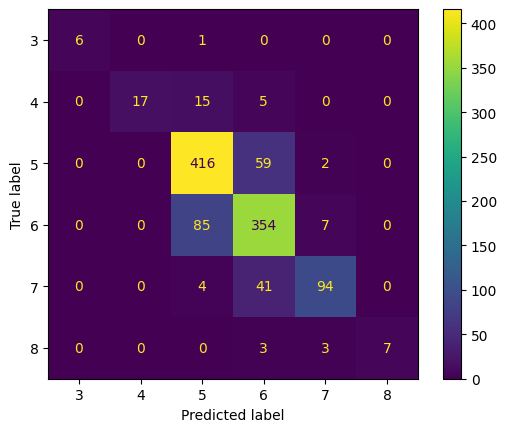

Test accuracy = 0.6145833333333334
Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.25      0.06      0.10        16
           5       0.68      0.75      0.71       204
           6       0.59      0.62      0.60       192
           7       0.48      0.35      0.40        60
           8       0.00      0.00      0.00         5

    accuracy                           0.61       480
   macro avg       0.33      0.30      0.30       480
weighted avg       0.59      0.61      0.60       480

Test Confusion Matrix


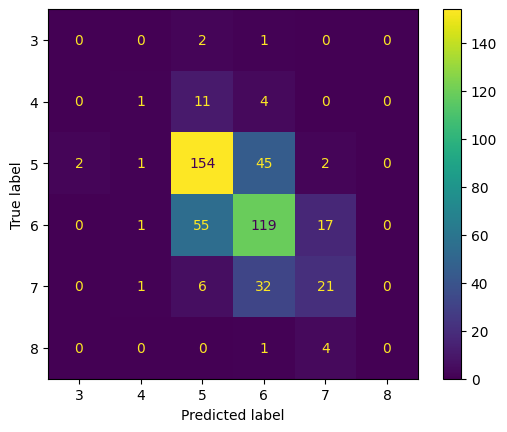

In [2]:
pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", svm.SVC(random_state=5))]
)

model_params = {'classify__decision_function_shape': ['ovo','ovr'],
                'classify__C': loguniform(1e-3, 1e3),
                'classify__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
                'classify__degree': randint(2, 5),
                'classify__gamma': loguniform(1e-4, 1e1)
               }

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params,
                                   n_iter=n_iter, verbose=3)

random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")
svm_best = random_search.best_estimator_

print(f"Training accuracy = {svm_best.score(X_train, y_train)}")
print('Training Classification Report')
print(classification_report(y_train, svm_best.predict(X_train)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(svm_best, X_train, y_train)
plt.show()

print(f"Test accuracy = {svm_best.score(X_test, y_test)}")
print('Test Classification Report')
print(classification_report(y_test, svm_best.predict(X_test)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(svm_best, X_test, y_test)
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END classify__activation=relu, classify__alpha=0.0007631668584043215, classify__hidden_layer_sizes=(64, 32), classify__solver=adam;, score=0.585 total time=  11.8s
[CV 2/5] END classify__activation=relu, classify__alpha=0.0007631668584043215, classify__hidden_layer_sizes=(64, 32), classify__solver=adam;, score=0.589 total time=   8.6s
[CV 3/5] END classify__activation=relu, classify__alpha=0.0007631668584043215, classify__hidden_layer_sizes=(64, 32), classify__solver=adam;, score=0.585 total time=   9.0s
[CV 4/5] END classify__activation=relu, classify__alpha=0.0007631668584043215, classify__hidden_layer_sizes=(64, 32), classify__solver=adam;, score=0.571 total time=   6.7s
[CV 5/5] END classify__activation=relu, classify__alpha=0.0007631668584043215, classify__hidden_layer_sizes=(64, 32), classify__solver=adam;, score=0.641 total time=   9.1s
[CV 1/5] END classify__activation=tanh, classify__alpha=1.074460273000546

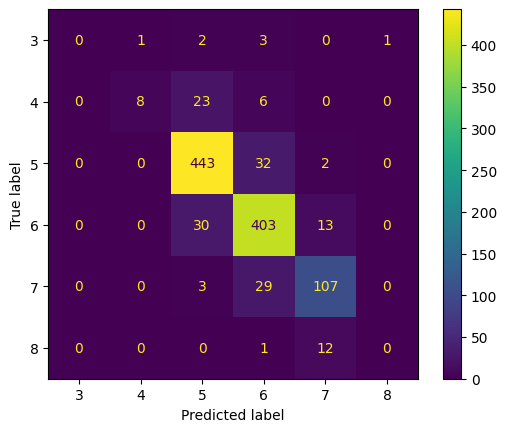

Test accuracy = 0.6270833333333333
Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.70      0.73      0.71       204
           6       0.60      0.66      0.63       192
           7       0.47      0.42      0.44        60
           8       0.00      0.00      0.00         5

    accuracy                           0.63       480
   macro avg       0.30      0.30      0.30       480
weighted avg       0.60      0.63      0.61       480

Test Confusion Matrix


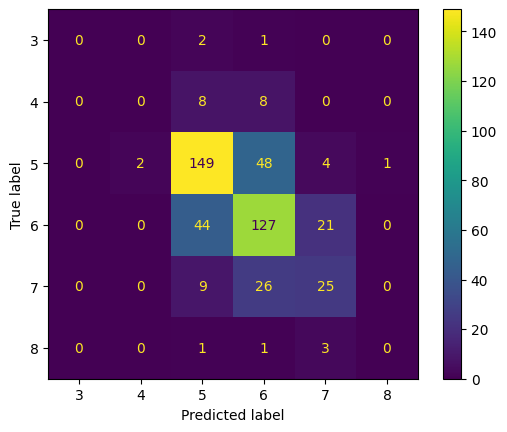

In [3]:
pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", MLPClassifier(max_iter=5000))]
)

model_params = {
    'classify__alpha': loguniform(1e-4, 10),
    'classify__solver': ['sgd','adam'],
    'classify__hidden_layer_sizes': [
        (100,),        
        (50, 25),      
        (32, 16, 8),     
        (64, 32)            
    ],
    'classify__activation': ['tanh','relu'] 
}

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)

start = time()
random_search.fit(X_train, y_train)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
        % ((time() - start), n_iter))

print(random_search.best_params_)
print(random_search.best_estimator_)

mlp_classifier_best = random_search.best_estimator_

print(f"Training accuracy = {mlp_classifier_best.score(X_train, y_train)}")
print('Training Classification Report')
print(classification_report(y_train, mlp_classifier_best.predict(X_train)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(mlp_classifier_best, X_train, y_train)
plt.show()

print(f"Test accuracy = {mlp_classifier_best.score(X_test, y_test)}")
print('Test Classification Report')
print(classification_report(y_test, mlp_classifier_best.predict(X_test)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(mlp_classifier_best, X_test, y_test)
plt.show()

In [4]:
# label_encoder = LabelEncoder()
# y_train_enc = label_encoder.fit_transform(y_train)
# y_test_enc = label_encoder.transform(y_test)
# num_classes = len(label_encoder.classes_)
# dtrain_clf = xgb.DMatrix(X_train, y_train_enc, enable_categorical=True)
# dtest_clf = xgb.DMatrix(X_test, y_test_enc, enable_categorical=True)

# params = {"objective": "multi:softprob", "num_class": num_classes}
# n = 1000

# model = xgb.train(
#    params=params,
#    dtrain=dtrain_clf,
#    num_boost_round=n
# )
# results = xgb.cv(
#    params, dtrain_clf,
#    num_boost_round=n,
#    nfold=5,
#    metrics=["mlogloss", "auc", "merror"])

# y_pred_train = model.predict(dtrain_clf)
# y_pred_test = model.predict(dtest_clf)

# y_pred_train_labels = label_encoder.inverse_transform(y_pred_train.argmax(axis=1))
# y_pred_test_labels = label_encoder.inverse_transform(y_pred_test.argmax(axis=1))

# print('Training Classification Report')
# print(classification_report(y_train, y_pred_train_labels))
# print('Training Confusion Matrix')
# ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_labels)
# plt.show()

# print('Test Classification Report')
# print(classification_report(y_test, y_pred_test_labels))
# print('Test Confusion Matrix')
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_labels)
# plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END classify__learning_rate=0.24013652311731398, classify__max_depth=6, classify__min_samples_leaf=3, classify__min_samples_split=6, classify__n_estimators=377, classify__subsample=0.508706980249412;, score=0.348 total time=   6.0s
[CV 2/5] END classify__learning_rate=0.24013652311731398, classify__max_depth=6, classify__min_samples_leaf=3, classify__min_samples_split=6, classify__n_estimators=377, classify__subsample=0.508706980249412;, score=0.460 total time=   5.8s
[CV 3/5] END classify__learning_rate=0.24013652311731398, classify__max_depth=6, classify__min_samples_leaf=3, classify__min_samples_split=6, classify__n_estimators=377, classify__subsample=0.508706980249412;, score=0.232 total time=   6.0s
[CV 4/5] END classify__learning_rate=0.24013652311731398, classify__max_depth=6, classify__min_samples_leaf=3, classify__min_samples_split=6, classify__n_estimators=377, classify__subsample=0.508706980249412;, score

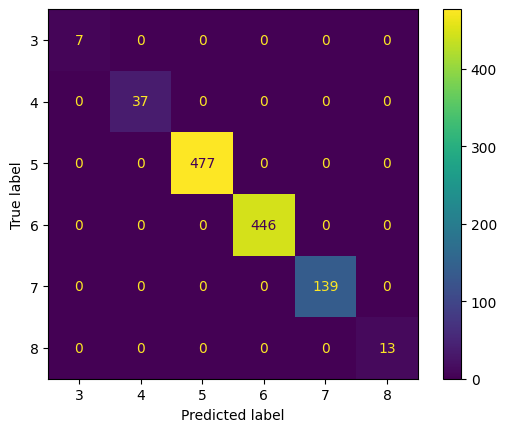

Test accuracy = 0.6729166666666667
Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.25      0.06      0.10        16
           5       0.73      0.79      0.76       204
           6       0.64      0.68      0.66       192
           7       0.60      0.50      0.55        60
           8       1.00      0.20      0.33         5

    accuracy                           0.67       480
   macro avg       0.54      0.37      0.40       480
weighted avg       0.66      0.67      0.66       480

Test Confusion Matrix


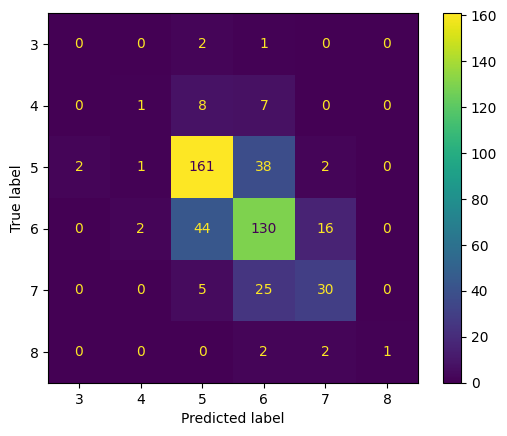

In [5]:
model_params = {'classify__n_estimators': randint(50, 500),
                'classify__learning_rate': loguniform(0.01, 1.0),
                'classify__max_depth': randint(2, 10),
                'classify__subsample': loguniform(0.5, 1.0),
                'classify__min_samples_split': randint(2, 10),
                'classify__min_samples_leaf': randint(1, 10)
               }

pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", GradientBoostingClassifier(random_state=5))]
)

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                     param_distributions=model_params, 
                                     n_iter=n_iter, verbose=3)

random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

gbc = random_search.best_estimator_

y_train_gbc = gbc.predict(X_train)
y_pred_gbc = gbc.predict(X_test)

print(f"Training accuracy = {gbc.score(X_train, y_train)}")
print('Training Classification Report')
print(classification_report(y_train, y_train_gbc, zero_division=0))
print('Training Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(gbc, X_train, y_train)
plt.show()

print(f"Test accuracy = {gbc.score(X_test, y_test)}")
print('Test Classification Report')
print(classification_report(y_test, y_pred_gbc, zero_division=0))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(gbc, X_test, y_test)
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END classify__max_depth=17, classify__min_samples_leaf=1, classify__min_samples_split=9, classify__n_estimators=83;, score=0.692 total time=   0.2s
[CV 2/5] END classify__max_depth=17, classify__min_samples_leaf=1, classify__min_samples_split=9, classify__n_estimators=83;, score=0.652 total time=   0.2s
[CV 3/5] END classify__max_depth=17, classify__min_samples_leaf=1, classify__min_samples_split=9, classify__n_estimators=83;, score=0.647 total time=   0.2s
[CV 4/5] END classify__max_depth=17, classify__min_samples_leaf=1, classify__min_samples_split=9, classify__n_estimators=83;, score=0.656 total time=   0.2s
[CV 5/5] END classify__max_depth=17, classify__min_samples_leaf=1, classify__min_samples_split=9, classify__n_estimators=83;, score=0.677 total time=   0.2s
[CV 1/5] END classify__max_depth=6, classify__min_samples_leaf=8, classify__min_samples_split=8, classify__n_estimators=171;, score=0.670 total time=   0

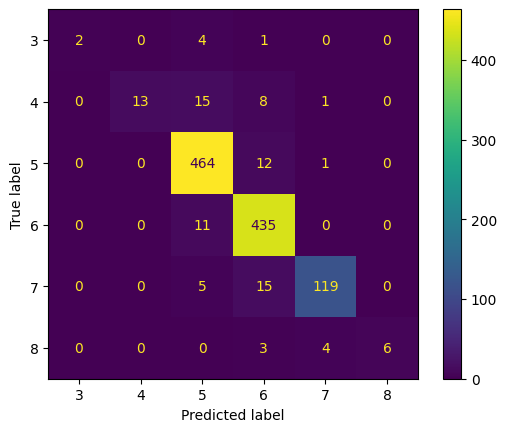

Test accuracy = 0.6666666666666666
Test Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.71      0.78      0.75       204
           6       0.63      0.69      0.66       192
           7       0.61      0.47      0.53        60
           8       0.00      0.00      0.00         5

    accuracy                           0.67       480
   macro avg       0.33      0.32      0.32       480
weighted avg       0.63      0.67      0.65       480

Test Confusion Matrix


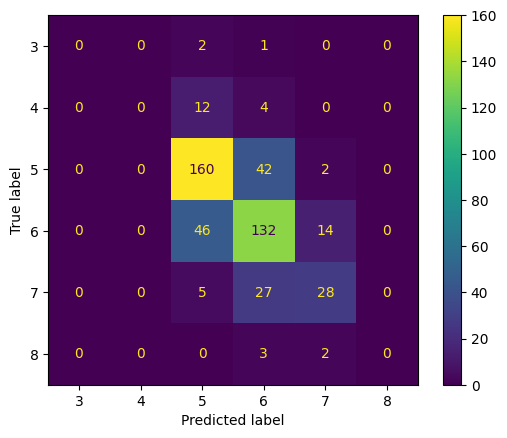

In [6]:
model_params = {'classify__n_estimators': randint(50,500),
              'classify__max_depth': randint(1,20),
              'classify__min_samples_split': randint(2, 10),
              'classify__min_samples_leaf': randint(1, 10)
              }

pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("classify", RandomForestClassifier(random_state=5))]
)

n_iter = 20
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)


random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

print('Best hyperparameters:',  random_search.best_params_)
print(f"Best cross-validation score: {random_search.best_score_}")

print(f"Training accuracy = {best_rf.score(X_train, y_train)}")
print('Training Classification Report')
print(classification_report(y_train, best_rf.predict(X_train)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(best_rf, X_train, y_train)
plt.show()

print(f"Test accuracy = {best_rf.score(X_test, y_test)}")
print('Test Classification Report')
print(classification_report(y_test, best_rf.predict(X_test)))
print('Test Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.show()